<a href="https://colab.research.google.com/github/correabra/-Lead_Gen_Business/blob/master/Desaf%C3%ADo_Detecci%C3%B3n_temprana_de_renuncias_en_empresa_de_telecomunicaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Descripción**

La oferta de servicios de telefonía ha ido en aumento en los últimos años, provocando una
alta competencia que se traduce en menores precios y mejores prestaciones. Sin embargo,
estas empresas luchan día a día por retener a sus clientes ya que el costo de un nuevo
cliente es mayor que el de retener a un cliente antiguo.
El objetivo de este desafío es entrenar un modelo de ensamble que permita predecir
tempranamente si un cliente renunciará a la compañía, además de poder explicar cuál o
cuáles son las características que más incidencia tienen en la separación de clientes con y
sin renuncia. Para esto deberás aplicar los conceptos y herramientas aprendidas hasta
ahora.
La muestra con la que se trabajará es un archivo llamado telecom_churn.csv, que contiene
los siguientes atributos asociados a clientes:
1. Churn (Variable objetivo): valor 1 si el cliente canceló el servicio, 0 si no
2. AccountWeeks: número de semanas que el cliente ha tenido activa la cuenta
3. ContractRenewal: toma el valor 1 si el cliente ha renovado recientemente el contrato,
0 en caso contrario
4. DataPlan: valor 1 si el cliente tiene plan de datos, 0 en caso contrario
5. DataUsage: Gigabytes de uso mensual de datos
6. CustServCalls: número de llamadas al servicio de atención al cliente
7. DayMins: promedio de minutos diurnos al mes
8. DayCalls: número medio de llamadas diurnas
9. MonthlyCharge: factura mensual media
10. OverageFee: mayor cuota de exceso en los últimos 12 meses
11. RoamMin: minutos de Roaming

Para lograr lo solicitado, debes realizar las siguientes tareas:
1. Importa las librerías necesarias y la base de datos, y realiza un análisis por variable
usando visualizaciones. Debes considerar las posibles correlaciones y representarlas
en un heatmap.
2. Desarrolla un modelo de árbol de decisión sin modificar sus hiper parámetros y
despliega sus métricas de desempeño. Luego, mejora este modelo de forma de
evitar el overfitting usando búsqueda por grilla con 5 kfold:
max_depth: [5, 10, 15, 20, 25]
min_samples_split: [0.01, 0.02, 0.03, 0.04]
Da a conocer los mejores hiper parámetros encontrados y el desempeño del modelo,
tanto en los datos de entrenamiento como en los de test.
3. Balancea las clases usando SMOTE para el conjunto de entrenamiento. Luego, aplica
un modelo de Bagging con 200 estimadores y muestra las métricas sobre el conjunto
de test.
4. Implementa un modelo de Bagging usando modelos heterogéneos con los
siguientes estimadores: Regresión Logística, Árbol de decisión, y dos SVM de
clasificación con kernel ‘rbf’ y ‘sigmoid’
. Para ello considera 200 muestras bootstrap
(T).
Debes calibrar la importancia de los modelos, repitiendo el modelo que sea más
importante en la lista de modelos a entrenar. Considera que un mejor modelo es
aquel con mejor f1-score. Muestra las métricas del modelo final aplicado al conjunto
de test. (Para realizar esta tarea utiliza la función bagging_het que se encuentra en el
archivo util_bagging.py)
5. Implementa un modelo de ensamble Random Forest usando como hiper parámetro
n_estimators = 45. El modelo debe usar muestra OOB para estimar su ajuste
ACCURACY , y debe mostrar las cuatro características más importantes junto con las
métricas de desempeño en el conjunto de test.
6. Realiza una búsqueda de grilla para un modelo Random Forest para los siguientes
rangos de valores para sus hiper parámetros:
n_estimators: 50 - 200 con paso de 10 completando 15 valores
max_features: [‘sqrt’
,
‘log2’
, None]

Muestra los mejores hiper parámetros encontrados, la estimación de desempeño en
los datos OOB, y despliega los cuatro atributos más importantes. ¿Tienen sentido
estos? Analiza además las métricas de desempeño, ROC y AUC.
Usando el modelo Random Forest con sus hiper parámetros ajustados, muestre los
15 clientes que presentan la mayor propensión a renunciar.

Punto 1. Importación de librerías, carga de archivos y análisis exploratorio (EDA)

In [ ]:
# ==========================================================
# PUNTO 1: IMPORTAR LIBRERÍAS
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [ ]:
# ==========================================================
# VERIFICAR ARCHIVOS Y CARGAR DATOS
# ==========================================================

import os

# Verificar que los archivos estén disponibles
print("Archivos disponibles en Colab:")
print(os.listdir())

# Importar función para usar más adelante en el Punto 4
from util_bagging import bagging_het

print("\n✓ util_bagging.py cargado correctamente")

# Cargar dataset
df = pd.read_csv('telecom_churn.csv')

print("\n✓ Dataset cargado correctamente")

print("\nPrimeras filas del dataset:")
display(df.head())

Archivos disponibles en Colab:
['.config', 'util_bagging.py', 'telecom_churn.csv', 'sample_data']

✓ util_bagging.py cargado correctamente

✓ Dataset cargado correctamente

Primeras filas del dataset:


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


Dimensiones del dataset:
(3333, 11)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB

Estadísticas descriptivas:


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000



Valores faltantes por variable:
Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64


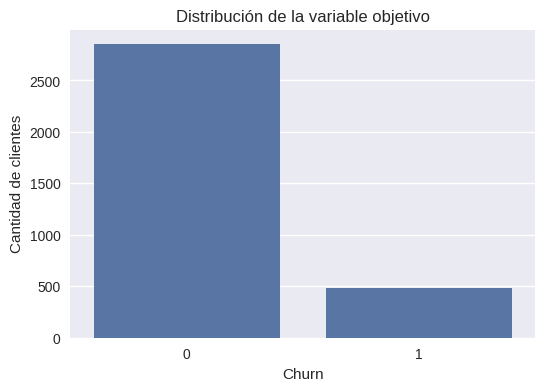


Frecuencia de Churn:
Churn
0    2850
1     483
Name: count, dtype: int64

Porcentaje de Churn:
Churn
0    85.508551
1    14.491449
Name: proportion, dtype: float64


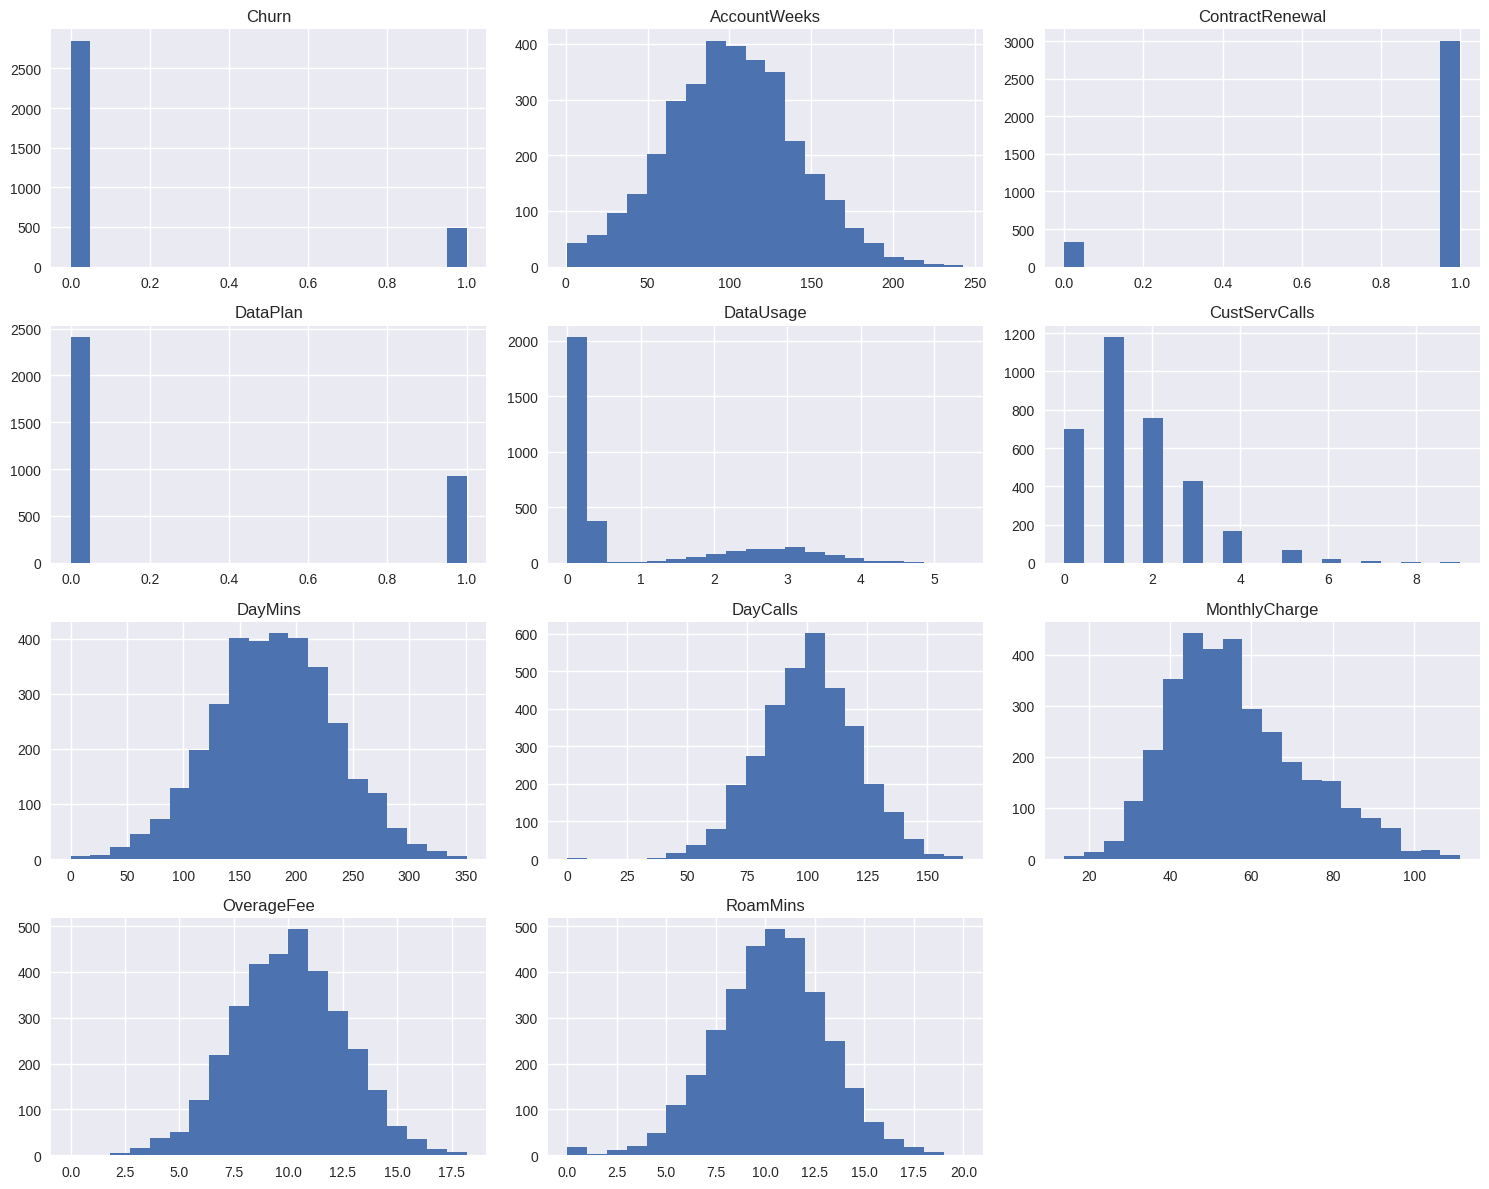

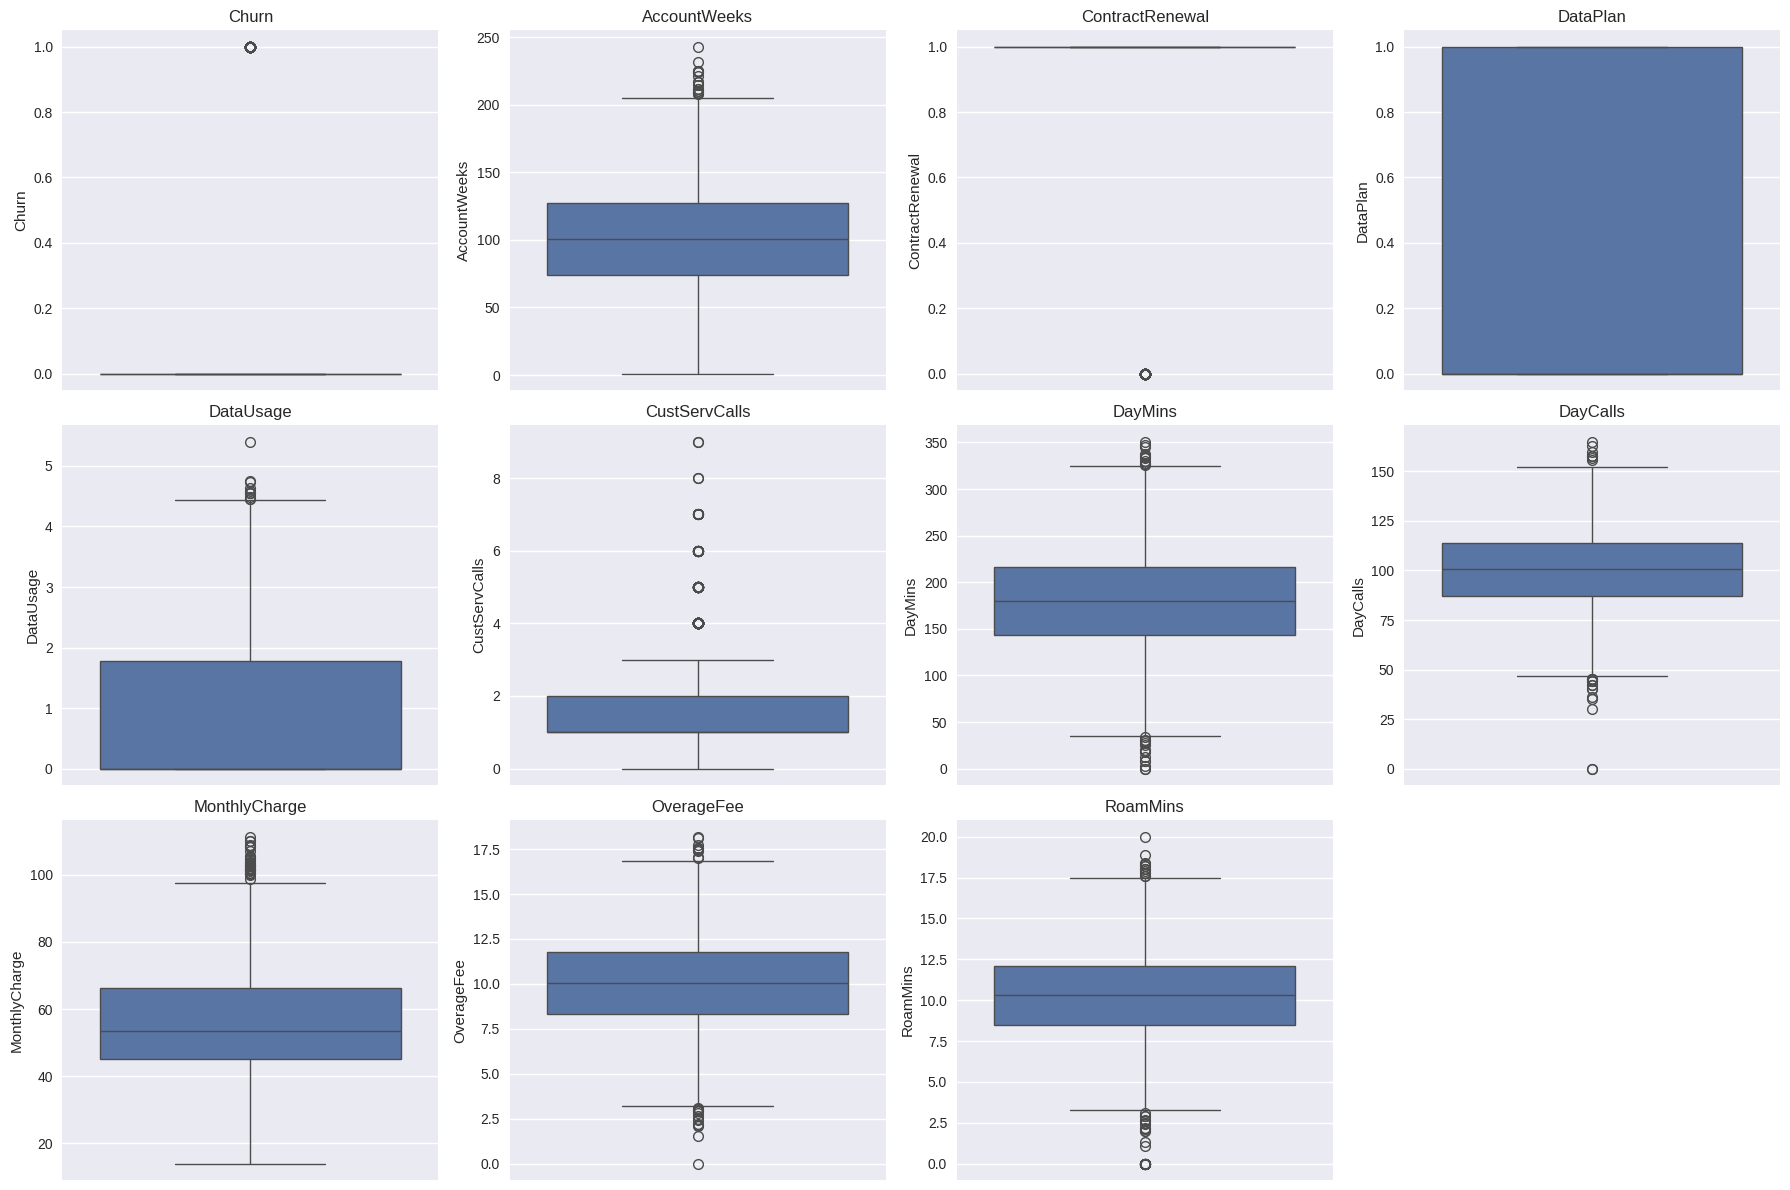

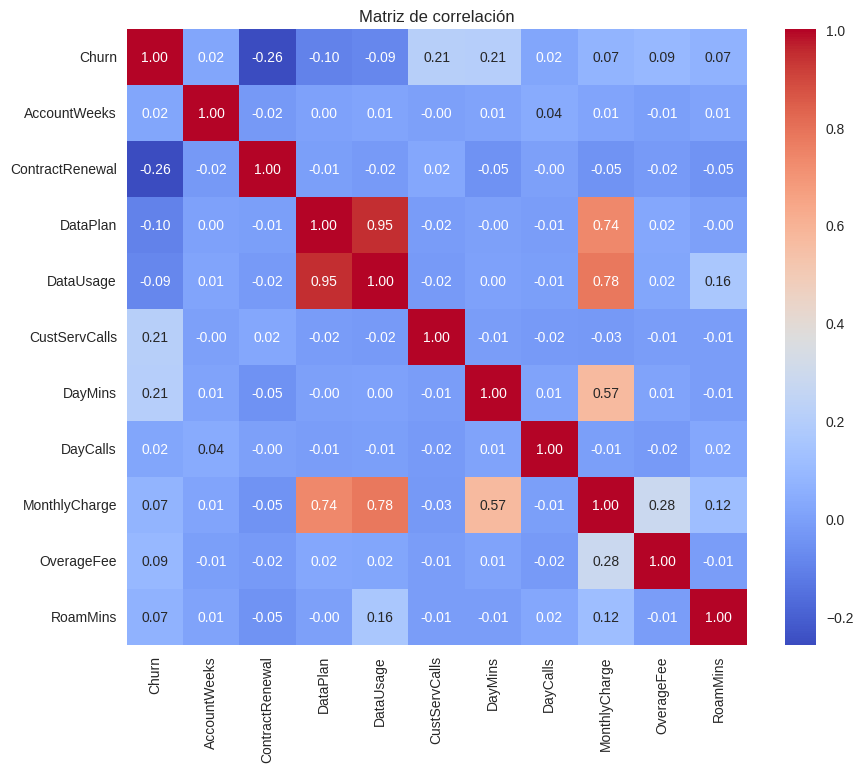


✓ Punto 1 finalizado correctamente.


In [ ]:
# ==========================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================================

# -----------------------------
# Dimensiones y estructura
# -----------------------------
print("Dimensiones del dataset:")
print(df.shape)

print("\nInformación general:")
df.info()

# -----------------------------
# Estadísticas descriptivas
# -----------------------------
print("\nEstadísticas descriptivas:")
display(df.describe())

# -----------------------------
# Valores faltantes
# -----------------------------
print("\nValores faltantes por variable:")
print(df.isnull().sum())

# -----------------------------
# Variable objetivo (Churn)
# -----------------------------
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Churn')

plt.title('Distribución de la variable objetivo')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')

plt.show()

print("\nFrecuencia de Churn:")
print(df['Churn'].value_counts())

print("\nPorcentaje de Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

# -----------------------------
# Histogramas
# -----------------------------
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()

# -----------------------------
# Boxplots
# -----------------------------
fig, axes = plt.subplots(3, 4, figsize=(18,12))

axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

# Ocultar ejes vacíos
for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# -----------------------------
# Heatmap de correlaciones
# -----------------------------
corr = df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación')

plt.show()

print("\n✓ Punto 1 finalizado correctamente.")


Punto 2. Árbol de Decisión

In [ ]:
# ==========================================================
# PREPARACIÓN DE LOS DATOS
# ==========================================================

# Variables predictoras
X = df.drop('Churn', axis=1)

# Variable objetivo
y = df['Churn']

# División entrenamiento (70%) y test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Dimensiones entrenamiento:")
print(X_train.shape)

print("\nDimensiones test:")
print(X_test.shape)

print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución de clases en test:")
print(y_test.value_counts(normalize=True) * 100)

Dimensiones entrenamiento:
(2333, 10)

Dimensiones test:
(1000, 10)

Distribución de clases en entrenamiento:
Churn
0    85.512216
1    14.487784
Name: proportion, dtype: float64

Distribución de clases en test:
Churn
0    85.5
1    14.5
Name: proportion, dtype: float64


¿Por qué usamos stratify=y?
Porque la variable objetivo está desbalanceada. Esto asegura que la proporción de clientes que renuncian y permanecen sea similar tanto en entrenamiento como en prueba.

In [ ]:
# ==========================================================
# ÁRBOL DE DECISIÓN BASE
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

# Modelo base
dt_base = DecisionTreeClassifier(random_state=42)

# Entrenamiento
dt_base.fit(X_train, y_train)

# Predicciones
y_train_pred = dt_base.predict(X_train)
y_test_pred = dt_base.predict(X_test)

# Probabilidades para ROC/AUC
y_test_prob = dt_base.predict_proba(X_test)[:, 1]

In [ ]:
# ==========================================================
# MÉTRICAS DEL ÁRBOL BASE
# ==========================================================

print("===== ENTRENAMIENTO =====")

print("Accuracy :", round(accuracy_score(y_train, y_train_pred), 4))
print("Precision:", round(precision_score(y_train, y_train_pred), 4))
print("Recall   :", round(recall_score(y_train, y_train_pred), 4))
print("F1-score :", round(f1_score(y_train, y_train_pred), 4))

print("\n===== TEST =====")

print("Accuracy :", round(accuracy_score(y_test, y_test_pred), 4))
print("Precision:", round(precision_score(y_test, y_test_pred), 4))
print("Recall   :", round(recall_score(y_test, y_test_pred), 4))
print("F1-score :", round(f1_score(y_test, y_test_pred), 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_test_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_test_pred))

===== ENTRENAMIENTO =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

===== TEST =====
Accuracy : 0.878
Precision: 0.5782
Recall   : 0.5862
F1-score : 0.5822

Matriz de confusión:
[[793  62]
 [ 60  85]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       855
           1       0.58      0.59      0.58       145

    accuracy                           0.88      1000
   macro avg       0.75      0.76      0.76      1000
weighted avg       0.88      0.88      0.88      1000



El árbol base presenta señales de sobreajuste (overfitting), ya que obtiene un desempeño prácticamente perfecto sobre los datos de entrenamiento, pero disminuye su capacidad predictiva sobre datos no observados.

In [ ]:
#Optimización mediante GridSearchCV
#El enunciado pide:
#max_depth: [5, 10, 15, 20, 25]
#min_samples_split: [0.01, 0.02, 0.03, 0.04]
#5-fold Cross Validation


# ==========================================================
# GRID SEARCH
# ==========================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [0.01, 0.02, 0.03, 0.04]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid.best_params_)

print("\nMejor F1-score CV:")
print(round(grid.best_score_, 4))

Mejores hiperparámetros:
{'max_depth': 15, 'min_samples_split': 0.01}

Mejor F1-score CV:
0.7022


¿Por qué usamos scoring='f1'?
Porque existe desbalance entre clases y el F1-score combina precisión y recall, siendo más informativo que la exactitud.

In [ ]:
# ==========================================================
# EVALUACIÓN DEL ÁRBOL OPTIMIZADO
# ==========================================================

dt_best = grid.best_estimator_

# Predicciones
y_train_pred_best = dt_best.predict(X_train)
y_test_pred_best = dt_best.predict(X_test)

print("===== ENTRENAMIENTO =====")

print("Accuracy :", round(accuracy_score(y_train, y_train_pred_best), 4))
print("Precision:", round(precision_score(y_train, y_train_pred_best), 4))
print("Recall   :", round(recall_score(y_train, y_train_pred_best), 4))
print("F1-score :", round(f1_score(y_train, y_train_pred_best), 4))

print("\n===== TEST =====")

print("Accuracy :", round(accuracy_score(y_test, y_test_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_test_pred_best), 4))
print("Recall   :", round(recall_score(y_test, y_test_pred_best), 4))
print("F1-score :", round(f1_score(y_test, y_test_pred_best), 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_test_pred_best))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_test_pred_best))

===== ENTRENAMIENTO =====
Accuracy : 0.9511
Precision: 0.8709
Recall   : 0.7781
F1-score : 0.8219

===== TEST =====
Accuracy : 0.917
Precision: 0.7348
Recall   : 0.669
F1-score : 0.7004

Matriz de confusión:
[[820  35]
 [ 48  97]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       855
           1       0.73      0.67      0.70       145

    accuracy                           0.92      1000
   macro avg       0.84      0.81      0.83      1000
weighted avg       0.91      0.92      0.92      1000



La búsqueda por grilla permitió identificar una configuración más adecuada del árbol de decisión, utilizando una profundidad máxima de 15 niveles y un mínimo del 1% de observaciones para realizar divisiones. Estos ajustes redujeron considerablemente el sobreajuste observado en el modelo inicial. En particular, el F1-score sobre el conjunto de prueba aumentó desde 0.5822 hasta 0.7004, demostrando una mejora relevante en la identificación de clientes con propensión a renunciar.

Punto 3. SMOTE + Bagging con 200 estimadores

In [ ]:
# ==========================================================
# PUNTO 3: IMPORTAR LIBRERÍAS
# ==========================================================

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [ ]:
# ==========================================================
# BALANCEO DE CLASES CON SMOTE
# ==========================================================

print("Distribución original de y_train:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nDistribución después de SMOTE:")
print(y_train_smote.value_counts())

Distribución original de y_train:
Churn
0    1995
1     338
Name: count, dtype: int64

Distribución después de SMOTE:
Churn
0    1995
1    1995
Name: count, dtype: int64


La aplicación de SMOTE permitió equilibrar completamente las clases del conjunto de entrenamiento, evitando que el modelo favorezca excesivamente a la clase mayoritaria.

In [ ]:
# ==========================================================
# MODELO BAGGING
# ==========================================================

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

bagging.fit(
    X_train_smote,
    y_train_smote
)

print("✓ Modelo Bagging entrenado")

✓ Modelo Bagging entrenado


In [ ]:
# ==========================================================
# MÉTRICAS DEL BAGGING
# ==========================================================

y_pred_bag = bagging.predict(X_test)

print("===== TEST =====")

print("Accuracy :", round(accuracy_score(y_test, y_pred_bag), 4))
print("Precision:", round(precision_score(y_test, y_pred_bag), 4))
print("Recall   :", round(recall_score(y_test, y_pred_bag), 4))
print("F1-score :", round(f1_score(y_test, y_pred_bag), 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_bag))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_bag))

===== TEST =====
Accuracy : 0.894
Precision: 0.6089
Recall   : 0.7517
F1-score : 0.6728

Matriz de confusión:
[[785  70]
 [ 36 109]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       855
           1       0.61      0.75      0.67       145

    accuracy                           0.89      1000
   macro avg       0.78      0.83      0.80      1000
weighted avg       0.91      0.89      0.90      1000



El uso combinado de SMOTE y Bagging permitió mejorar significativamente la capacidad del modelo para identificar clientes con propensión a renunciar, incrementando el Recall desde 0.6690 hasta 0.7517. Sin embargo, esta mejora vino acompañada de una disminución en la Precision, reduciendo el F1-score global respecto del árbol optimizado. En consecuencia, aunque el ensamble resultó más sensible para detectar clientes en riesgo, el Árbol de Decisión optimizado continuó presentando el mejor equilibrio general entre precisión y recall.

El uso combinado de SMOTE y Bagging permitió mejorar significativamente la capacidad del modelo para identificar clientes con propensión a renunciar, incrementando el Recall desde 0.6690 hasta 0.7517. Sin embargo, esta mejora vino acompañada de una disminución en la Precision, reduciendo el F1-score global respecto del árbol optimizado. En consecuencia, aunque el ensamble resultó más sensible para detectar clientes en riesgo, el Árbol de Decisión optimizado continuó presentando el mejor equilibrio general entre precisión y recall.

Punto 4. Bagging heterogéneo

El enunciado solicita:

Implementar un modelo de Bagging usando modelos heterogéneos con los siguientes estimadores:

-Regresión Logística

-Árbol de decisión


-SVM con kernel 'rbf'


-SVM con kernel 'sigmoid'

utilizando 200 muestras bootstrap.

Además, se debe calibrar la importancia de los modelos, repitiendo el modelo con mejor F1-score dentro de la lista de estimadores.


Estrategia

Vamos a hacerlo en 4 pasos:

1. Evaluar individualmente los 4 modelos.

2. Identificar cuál tiene el mejor F1-score.

3. Darle mayor peso repitiéndolo en la lista de estimadores.

4. Construir el Bagging heterogéneo con bagging_het().

In [ ]:
# ==========================================================
# PUNTO 4: IMPORTAR LIBRERÍAS
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.base import clone

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [ ]:
# ==========================================================
# EVALUACIÓN INDIVIDUAL DE LOS MODELOS
# Utilizaremos los datos originales de entrenamiento (X_train, y_train).
# ==========================================================

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'SVM RBF': SVC(
        kernel='rbf',
        random_state=42
    ),

    'SVM Sigmoid': SVC(
        kernel='sigmoid',
        random_state=42
    )
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)

    results[name] = f1

    print(f"\n{name}")
    print("-"*30)
    print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
    print("Precision:", round(precision_score(y_test, y_pred),4))
    print("Recall   :", round(recall_score(y_test, y_pred),4))
    print("F1-score :", round(f1,4))


Logistic Regression
------------------------------
Accuracy : 0.868
Precision: 0.6275
Recall   : 0.2207
F1-score : 0.3265

Decision Tree
------------------------------
Accuracy : 0.878
Precision: 0.5782
Recall   : 0.5862
F1-score : 0.5822

SVM RBF
------------------------------
Accuracy : 0.859
Precision: 1.0
Recall   : 0.0276
F1-score : 0.0537

SVM Sigmoid
------------------------------
Accuracy : 0.776
Precision: 0.101
Recall   : 0.069
F1-score : 0.082


In [ ]:
# ==========================================================
# MEJOR MODELO SEGÚN F1-SCORE
# ==========================================================

best_model_name = max(results, key=results.get)

print("Mejor modelo:", best_model_name)
print("F1-score:", round(results[best_model_name],4))

Mejor modelo: Decision Tree
F1-score: 0.5822


In [ ]:
# ==========================================================
# LISTA DE ESTIMADORES PONDERADA
# ==========================================================

estimators = [
    LogisticRegression(max_iter=1000, random_state=42),

    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42),

    SVC(kernel='rbf', random_state=42),

    SVC(kernel='sigmoid', random_state=42)
]

print("✓ Lista de estimadores creada")

✓ Lista de estimadores creada


In [ ]:
# ==========================================================
# BAGGING HETEROGÉNEO
# El enunciado exige: T = 200 bootstrap
# ==========================================================

trained_models, yhat_test_all, yhat_final, idx_oob = bagging_het(
    X_train=X_train,
    y_train=y_train,
    T=200,
    estimators=estimators,
    X_test=X_test
)

print("✓ Bagging heterogéneo entrenado")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✓ Bagging heterogéneo entrenado


In [ ]:
# ==========================================================
# MÉTRICAS DEL BAGGING HETEROGÉNEO
# ==========================================================

print("===== TEST =====")

print("Accuracy :", round(accuracy_score(y_test, yhat_final),4))
print("Precision:", round(precision_score(y_test, yhat_final),4))
print("Recall   :", round(recall_score(y_test, yhat_final),4))
print("F1-score :", round(f1_score(y_test, yhat_final),4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, yhat_final))

print("\nReporte de clasificación:")
print(classification_report(y_test, yhat_final))

===== TEST =====
Accuracy : 0.886
Precision: 0.9697
Recall   : 0.2207
F1-score : 0.3596

Matriz de confusión:
[[854   1]
 [113  32]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       855
           1       0.97      0.22      0.36       145

    accuracy                           0.89      1000
   macro avg       0.93      0.61      0.65      1000
weighted avg       0.90      0.89      0.85      1000



El Bagging heterogéneo mejoró significativamente al otorgar mayor peso al Árbol de Decisión, aumentando el F1-score desde 0.0667 hasta 0.3596. No obstante, el modelo continuó presentando un bajo Recall (0.2207), lo que evidencia dificultades para identificar a la mayoría de los clientes con propensión a renunciar. En consecuencia, este enfoque no logró superar el desempeño del Árbol de Decisión optimizado ni del Bagging con SMOTE.

El Bagging heterogéneo mejoró significativamente al otorgar mayor peso al Árbol de Decisión, aumentando el F1-score desde 0.0667 hasta 0.3596. No obstante, el modelo continuó presentando un bajo Recall (0.2207), lo que evidencia dificultades para identificar a la mayoría de los clientes con propensión a renunciar. En consecuencia, este enfoque no logró superar el desempeño del Árbol de Decisión optimizado ni del Bagging con SMOTE.

Punto 5. Random Forest con OOB

Implementar un modelo de ensamble Random Forest usando:

-n_estimators = 45

-muestra OOB (Out-of-Bag) para estimar su ajuste mediante Accuracy

-mostrar las 4 características más importantes

-desplegar las métricas de desempeño sobre el conjunto de test.



In [ ]:
# ==========================================================
# PUNTO 5: RANDOM FOREST
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=45,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("✓ Random Forest entrenado")

✓ Random Forest entrenado


In [ ]:
# ==========================================================
# ACCURACY OOB
# ==========================================================

print("Accuracy OOB:")
print(round(rf.oob_score_, 4))

Accuracy OOB:
0.9258


El modelo presenta una estimación OOB de 93%, indicando una buena capacidad de generalización sobre observaciones no utilizadas durante la construcción de cada árbol.

In [ ]:
# ==========================================================
# MÉTRICAS RANDOM FOREST
# ==========================================================

y_pred_rf = rf.predict(X_test)

print("===== TEST =====")

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1-score :", round(f1_score(y_test, y_pred_rf), 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

===== TEST =====
Accuracy : 0.929
Precision: 0.8083
Recall   : 0.669
F1-score : 0.7321

Matriz de confusión:
[[832  23]
 [ 48  97]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       855
           1       0.81      0.67      0.73       145

    accuracy                           0.93      1000
   macro avg       0.88      0.82      0.85      1000
weighted avg       0.93      0.93      0.93      1000



In [ ]:
# ==========================================================
# IMPORTANCIA DE VARIABLES
# ==========================================================

importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
})

importances = importances.sort_values(
    by='Importancia',
    ascending=False
)

print("Las 4 variables más importantes son:")

display(importances.head(4))

Las 4 variables más importantes son:


,Variable,Importancia
5,DayMins,0.193813
7,MonthlyCharge,0.166603
4,CustServCalls,0.138815
8,OverageFee,0.092467


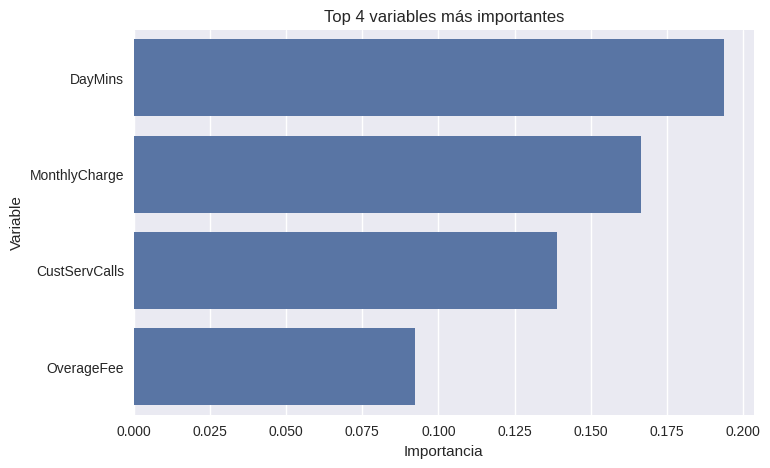

In [ ]:
# ==========================================================
# GRÁFICO DE IMPORTANCIA
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=importances.head(4),
    x='Importancia',
    y='Variable'
)

plt.title('Top 4 variables más importantes')
plt.xlabel('Importancia')
plt.ylabel('Variable')

plt.show()

El modelo Random Forest con 45 árboles presentó el mejor desempeño global entre todos los modelos evaluados.
Obtuvo un Accuracy de 92.9% y un F1-score de 0.7321 sobre el conjunto de prueba, superando tanto al Árbol de Decisión optimizado como a los distintos enfoques de Bagging.
Asimismo, la estimación OOB (92.58%) fue consistente con el desempeño observado en test, evidenciando una adecuada capacidad de generalización.
Finalmente, las variables más importantes identificadas por el modelo fueron DayMins, MonthlyCharge, CustServCalls y OverageFee, las cuales presentan una interpretación coherente dentro del contexto del abandono de clientes.

6. Grid Search para Random Forest

Realizar una búsqueda de grilla para Random Forest considerando:

n_estimators: 15 valores entre 50 y 190 con paso 10.

max_features: ['sqrt', 'log2', None]

Y luego:

-Mostrar los mejores hiperparámetros.

-Mostrar el Accuracy OOB del mejor modelo.

-Mostrar las 4 variables más importantes.

-Analizar las métricas de desempeño.

-Mostrar ROC y AUC.

In [ ]:
# ==========================================================
# PUNTO 6: GRID SEARCH RANDOM FOREST
# ==========================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': list(range(50, 200, 10)),   # 50 a 190
    'max_features': ['sqrt', 'log2', None]
}

rf_grid = RandomForestClassifier(
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

grid_rf = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("✓ Grid Search finalizado")

✓ Grid Search finalizado


In [ ]:
# ==========================================================
# MEJORES HIPERPARÁMETROS
# ==========================================================

print("Mejores hiperparámetros:")
print(grid_rf.best_params_)

print("\nMejor F1-score CV:")
print(round(grid_rf.best_score_, 4))

Mejores hiperparámetros:
{'max_features': 'sqrt', 'n_estimators': 70}

Mejor F1-score CV:
0.7525


In [ ]:
# ==========================================================
# MEJOR RANDOM FOREST
# ==========================================================

best_rf = grid_rf.best_estimator_

print("Accuracy OOB:")
print(round(best_rf.oob_score_, 4))

Accuracy OOB:
0.9336


In [ ]:
# ==========================================================
# MÉTRICAS DEL MEJOR RANDOM FOREST
# ==========================================================

y_pred_best = best_rf.predict(X_test)

print("===== TEST =====")

print("Accuracy :", round(accuracy_score(y_test, y_pred_best),4))
print("Precision:", round(precision_score(y_test, y_pred_best),4))
print("Recall   :", round(recall_score(y_test, y_pred_best),4))
print("F1-score :", round(f1_score(y_test, y_pred_best),4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_best))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_best))

===== TEST =====
Accuracy : 0.93
Precision: 0.8319
Recall   : 0.6483
F1-score : 0.7287

Matriz de confusión:
[[836  19]
 [ 51  94]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       855
           1       0.83      0.65      0.73       145

    accuracy                           0.93      1000
   macro avg       0.89      0.81      0.84      1000
weighted avg       0.93      0.93      0.93      1000



AUC: 0.8758


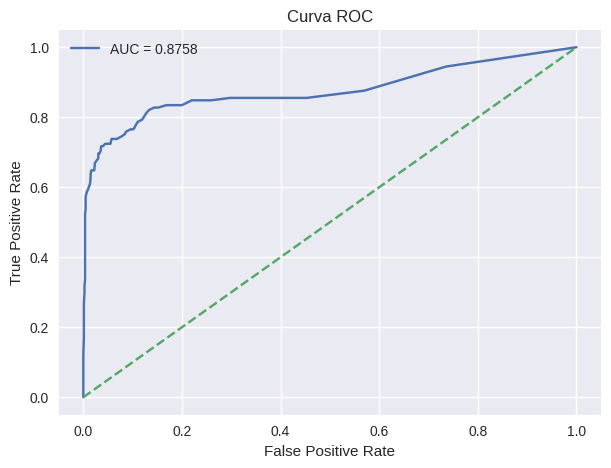

In [ ]:
# ==========================================================
# CURVA ROC Y AUC
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", round(auc,4))

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')

plt.legend()

plt.show()

In [ ]:
# ==========================================================
# IMPORTANCIA DE VARIABLES
# ==========================================================

importances_best = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': best_rf.feature_importances_
})

importances_best = importances_best.sort_values(
    by='Importancia',
    ascending=False
)

display(importances_best.head(4))

,Variable,Importancia
5,DayMins,0.202542
7,MonthlyCharge,0.152095
4,CustServCalls,0.143864
8,OverageFee,0.096740


Punto 7 . 15 clientes que presentan la mayor propensión a renunciar

In [ ]:
# ==========================================================
# TOP 15 CLIENTES CON MAYOR PROPENSIÓN A RENUNCIAR
# ==========================================================

prob_churn = best_rf.predict_proba(X_test)[:,1]

top15 = pd.DataFrame(X_test).copy()

top15['Probabilidad_Churn'] = prob_churn

top15 = top15.sort_values(
    by='Probabilidad_Churn',
    ascending=False
)

display(top15.head(15))

,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,Probabilidad_Churn
2099,71,1,0,0.00,3,290.4,108,71.0,12.70,10.1,1.000000
832,87,1,0,0.00,2,322.5,106,73.0,10.23,9.4,1.000000
894,97,1,0,0.00,4,120.8,96,35.0,8.49,11.9,1.000000
306,113,1,0,0.00,1,272.1,111,70.0,13.43,8.5,1.000000
2113,60,1,0,0.00,2,289.8,101,71.0,12.78,11.7,0.985714
1038,112,1,0,0.00,5,111.9,92,29.0,5.70,14.1,0.985714
3205,111,1,0,0.00,1,294.7,90,76.0,14.73,10.8,0.985714
2924,96,1,0,0.00,1,276.9,105,69.0,12.35,10.3,0.985714
2979,99,1,0,0.12,7,135.7,107,42.2,10.42,8.8,0.985714
1984,112,1,0,0.00,3,272.5,119,66.0,11.31,16.4,0.971429


A partir de la comparación de los distintos modelos de clasificación, se concluye que los enfoques basados en ensambles presentaron el mejor desempeño para la predicción temprana del churn. El Random Forest ajustado mediante Grid Search alcanzó un Accuracy de 93% y un AUC de 0,8758, demostrando una excelente capacidad discriminativa. Sin embargo, considerando el equilibrio entre precisión y recall medido a través del F1-score, el modelo Random Forest con 45 árboles obtuvo el mejor resultado global (F1-score = 0,7321), constituyéndose como la alternativa más adecuada para apoyar estrategias de retención de clientes en la compañía de telecomunicaciones.